In [1]:
import os

os.chdir(r"E:\Future Interns\Task 2 - Support Ticket Classification\Code")

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

In [3]:
df=pd.read_csv("all_tickets_processed_improved_v3.csv")
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


In [5]:
#------DATA CLEANING--------
#Check missing values
df.isnull().sum()

Document       0
Topic_group    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# spot-check 3 random rows per class
for topic_grp in df['Topic_group'].unique():
    print(f'\n=== {topic_grp} ===')
    samples = df[df['Topic_group'] == topic_grp]['Document'].sample(10)
    for s in samples:
        print(f'  → {s[:120]}')


=== Hardware ===
  → stack cables for re stack cables please dispatching assign thank december stack cables hi please received stack cables p
  → error on careers com sent thursday error careers importance high hi your career down experiencing some error chrome ie p
  → ms service ops it ops extension pm extension hello please extension number which client calls forwarded lead
  → urgent help required please urgent help required please hi today for some reason cannot seem connect via open log normal
  → for on authentication issue sent tuesday hello cannot access for could you please let know correct passwords attached ho
  → access to building november pm va la si la tot la ext
  → separate on th floor wednesday separate floor hi ability multiple connecting once least meeting rooms floor after discus
  → monitor thursday october pm monitor hello please create replace monitor creative design monitor additionally design mous
  → access to november pm error hi please help resolve error 

In [8]:
keywords = {
    'Hardware': [
        'laptop','desktop','monitor','keyboard','mouse',
        'dock','headset','camera','webcam','printer',
        'ram','battery','screen','charger','backpack'
    ],

    'Access': [
        'access','password','login','account',
        'unlock','confluence','vpn','permission',
        'credentials','reset'
    ],

    'Purchase': [
        'purchase','po','procurement',
        'order','vendor','buy'
    ],

    'HR Support': [
        'leave','maternity','joining',
        'employee','oracle','attendance',
        'timesheet','holiday'
    ],

    'Storage': [
        'sharepoint','onedrive','drive',
        'folder','library','storage',
        'mailbox','archive'
    ],

    'Administrative rights': [
        'administrator','admin',
        'elevated','install',
        'privilege','permission'
    ],

    'Internal Project': [
        'project','deployment','report',
        'setup','development'
    ]
}

In [9]:
print(df['Topic_group'].value_counts())

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


In [10]:
#----------TEXT PREPROCESSING----------

In [11]:
import re
import string
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from itertools import groupby

stop_words = set(stopwords.words("english"))
days = {
    "monday","tuesday","wednesday",
    "thursday","friday","saturday","sunday"
}

months = {
    "january","february","march","april",
    "may","june","july","august",
    "september","october","november","december"
}
email_stops = {
    'please', 'help','hi', 'hello', 'dear', 'regards', 'kind',
    'thank', 'thanks', 'pm', 're', 'sent', 'best',
    'engineer', 'senior', 'lead', 'let', 'know',
    'ext', 'attached', 'also', 'would',
    'could', 'need', 'get', 'one', 'like', 'date'
}
time_words = {"am","pm"}

stop_words.update(days)
stop_words.update(months)
stop_words.update(time_words)
stop_words.update(email_stops)
lemmatizer = WordNetLemmatizer()

In [12]:
def get_wordnet_pos(tag):
    """Map NLTK POS tag to WordNet POS for accurate lemmatization."""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN  # default

def remove_consecutive_duplicates(words):
    result = []
    for word in words:
        if not result or result[-1] != word:
            result.append(word)
    return result


In [13]:
import contractions
def clean_text(text):
    text = str(text)
    text = contractions.fix(text)          # STEP 1 — before any split
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)      # remove email
    text = re.sub(r'<.*?>', '', text)              # remove HTML tags
    text = text.replace('_', ' ')
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\b\d+\b", " ", text)             # remove digits
    #text = re.sub(r'\b\w{1,2}\b', ' ', text)      # remove 1-2 char tokens
    text = re.sub(r'\s+', ' ', text).strip()

    words = word_tokenize(text)
    #words = remove_consecutive_duplicates(words)
    words = [k for k, _ in groupby(words)]
    pos_tags = pos_tag(words)                      # POS tag for all words
    words = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]
    words = [w for w in words if w not in stop_words and len(w) > 2]
    seen = set()
    words = [w for w in words if not (w in seen or seen.add(w))]
    return " ".join(words)

In [14]:
df['Clean Text']=df['Document'].apply(clean_text)
df['Clean Text'].head(10)

0                     connection icon setup per detail
1    work experience user student come next name mu...
2    request meet meeting follow equipment cable co...
3    reset password external account expire day ask...
4    mail verification warn attach address regard m...
5    mail look blacklist receive anymore sample regard
6    prod server tunnel host card port name bytes s...
7        access request module report cost much regard
8                                reset password client
9    direct report miss time action way close mater...
Name: Clean Text, dtype: object

In [15]:
df.isnull().sum()
empty=[(i,s) for i,s in enumerate(df['Clean Text']) if len(s)==0]
empty

[(10655, ''), (13898, ''), (32138, ''), (33467, ''), (35590, ''), (41259, '')]

In [16]:
df['Topic_group']=[str(text).lower() for text in df['Topic_group']]

In [17]:
print(df['Document'][0])
print('***cleaned***')
print(df['Clean Text'][0])

connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead
***cleaned***
connection icon setup per detail


In [18]:
df['Word Count'] = df['Clean Text'].apply(
    lambda x: len(x.split())
)
df['Word Count'].describe()

count    47837.000000
mean        18.729289
std         20.338404
min          0.000000
25%          7.000000
50%         12.000000
75%         21.000000
max        320.000000
Name: Word Count, dtype: float64

In [39]:
'''
import re
import pandas as pd

# 1. Define the priority keywords dictionary
priority_keywords2= {
    "Critical": [
        "critical", "urgent", "emergency", "immediate", "escalate", "escalation"
    ],
    "High": [
        "high", "importance", "higher", "highest", "top"
    ],
    "Medium": [
        "medium", "normal", "moderate"
    ],
    "Low": [
        "low", "routine"
    ]
}

# 2. Define the priority assignment function
def assign_priority2(text, keywords_dict=priority_keywords, default_priority="Low"):
    """
    Assigns a priority tier based on keywords found in the text.
    Checks in hierarchical order: Critical -> High -> Medium -> Low.
    """
    if pd.isna(text) or not isinstance(text, str):
        return default_priority
    
    text_lower = text.lower()
    
    # Check tiers from highest severity to lowest
    for priority_tier in ["Critical", "High", "Medium", "Low"]:
        for keyword in keywords_dict[priority_tier]:
            # Using \b word boundaries to match exact words (prevents matching 'highlight' as 'high')
            if re.search(r'\b' + re.escape(keyword) + r'\b', text_lower):
                return priority_tier
                
    return default_priority'''

'\nimport re\nimport pandas as pd\n\n# 1. Define the priority keywords dictionary\npriority_keywords2= {\n    "Critical": [\n        "critical", "urgent", "emergency", "immediate", "escalate", "escalation"\n    ],\n    "High": [\n        "high", "importance", "higher", "highest", "top"\n    ],\n    "Medium": [\n        "medium", "normal", "moderate"\n    ],\n    "Low": [\n        "low", "routine"\n    ]\n}\n\n# 2. Define the priority assignment function\ndef assign_priority2(text, keywords_dict=priority_keywords, default_priority="Low"):\n    """\n    Assigns a priority tier based on keywords found in the text.\n    Checks in hierarchical order: Critical -> High -> Medium -> Low.\n    """\n    if pd.isna(text) or not isinstance(text, str):\n        return default_priority\n\n    text_lower = text.lower()\n\n    # Check tiers from highest severity to lowest\n    for priority_tier in ["Critical", "High", "Medium", "Low"]:\n        for keyword in keywords_dict[priority_tier]:\n           

In [37]:
priority_keywords = {

    'Critical': [
        # All verified ✓ (100+ occurrences) in your dataset
        'urgent',       # 1,795
        'urgently',     # 255
        'asap',         # 858
        'immediately',  # 561
        'critical',     # 703
        'emergency',    # 202
        'escalate',     # 73
        'escalation',   # 56
        'outage',       # 221
        'broken',       # 402
        'failed',       # 1,510
        'failure',      # 340
        'cannot',       # 4,643
        'unable',       # 2,318
        'blocked',      # 227
        'blocking',     # 143
        'persists',     # 89
        'down',         # 1,693
        # Removed: 'not working'(0), 'crashed'(38), 'severe'(17) — too rare
    ],

    'High': [
        # All verified ✓ in your dataset
        'importance',   # 3,592
        'important',    # 759
        'deadline',     # 242
        'delay',        # 176
        'delayed',      # 62
        'overdue',      # 49
        'slow',         # 392
        'impact',       # 359
        'affecting',    # 68
        'reoccurring',  # 77
        'dependency',   # 53
        # Removed: 'error'(9291), 'issue'(8802), 'problem'(3901),
        # 'high'(4439), 'priority'(1238) — too generic, appear in all classes
    ],

    'Medium': [
        # Action/service request words — all verified ✓
        'setup',        # 2,197
        'install',      # 1,530
        'configure',    # 107
        'create',       # 4,903
        'update',       # 5,601
        'request',      # 4,287
        'assign',       # 2,989
        'change',       # 7,816
        'provide',      # 4,758
        'check',        # 2,168
        'review',       # 2,004
        'upgrade',      # 3,286
        'approval',     # 2,680
        'approve',      # 2,244
        'submit',       # 3,286
        'password',     # 2,970
        'license',      # 2,047
        'delete',       # 2,472
        'move',         # 901
        'share',        # 1,320
        'connect',      # 2,021
        'reset',        # 1,147
        'enable',       # 721
        'disable',      # 476
        # Removed: 'access'(13k), 'add'(7k), 'log'(7k), 'change'(7k)
        # — kept only unambiguous action words
    ],

    'Low': [
        # Informational / non-urgent — all verified ✓
        'query',        # 686
        'question',     # 740
        'suggestion',   # 85
        'whenever',     # 115
        'future',       # 565
        'upcoming',     # 685
        'advise',       # 2,856
        'possible',     # 3,048
        'interested',   # 127
        'proposal',     # 176
        'swap',         # 332
        'budget',       # 250
        'virtual',      # 616
        # Removed: 'information'(6500), 'note'(3290) — too generic
        # Removed: 'fyi'(0), 'enhancement'(20), 'convenient'(26) — too rare
    ],
}


def assign_priority(text):
    text = str(text).lower()
    words = set(re.findall(r'\b[a-z]+\b', text))  # clean word boundaries
    for priority in ['Critical', 'High', 'Medium', 'Low']:
        for keyword in priority_keywords[priority]:
            if ' ' in keyword:
                if keyword in text:
                    return priority
            else:
                if keyword in words:
                    return priority
    return 'Medium'  # default

In [20]:
print("topic: documnet")
for (i,s) in empty:
    print(f"{df["Topic_group"][i]}: {df['Document'][i]},{df['Word Count'][i]}")

topic: documnet
hardware: for pm la la,0
purchase: po pm re hi done,0
hr support: on thursday hi please thank,0
hardware: de tuesday july pm,0
administrative rights: for is down again for down again hi for down again,0
access: need on the pc need pc,0


In [21]:
df = df[df["Word Count"] > 0]

In [22]:
for i,s in enumerate(df['Clean Text']):
    if len(s)==0:
        print(i,s)

In [38]:
#assign priority

df['Priority'] = df['Document'].apply(assign_priority)
print(df['Priority'].value_counts())
print(df['Priority'].value_counts(normalize=True).mul(100).round(1))

Priority
Medium      35241
Critical     8522
High         2480
Low          1588
Name: count, dtype: int64
Priority
Medium      73.7
Critical    17.8
High         5.2
Low          3.3
Name: proportion, dtype: float64


In [90]:
#---------Text EDA---------

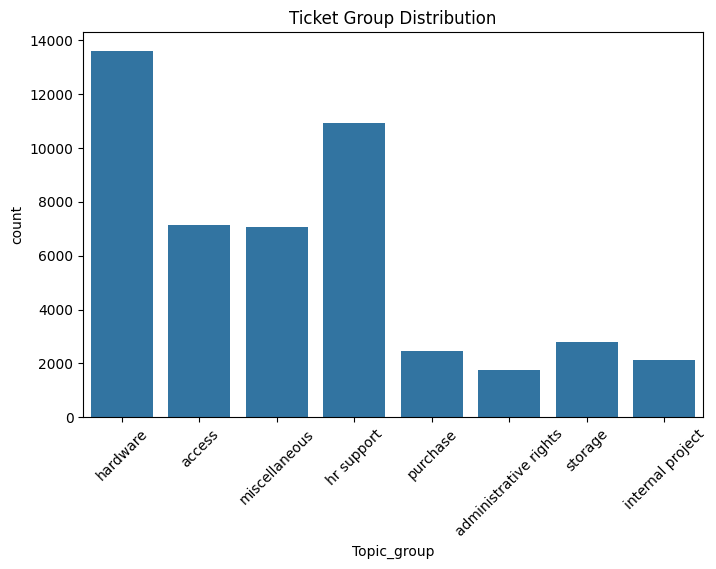

In [91]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Topic_group')
plt.xticks(rotation=45)
plt.title("Ticket Group Distribution")
plt.savefig("Ticket Group Distribution", dpi=300, bbox_inches='tight')
plt.show()

In [92]:
print(df.head())
print(df.isnull().sum())

                                            Document    Topic_group  \
0  connection with icon icon dear please setup ic...       hardware   
1  work experience user work experience user hi w...         access   
2  requesting for meeting requesting meeting hi p...       hardware   
3  reset passwords for external accounts re expir...         access   
4  mail verification warning hi has got attached ...  miscellaneous   

                                          Clean Text  Word Count  
0                   connection icon setup per detail           5  
1  work experience user student come next name mu...          10  
2  request meet meeting follow equipment cable co...           8  
3  reset password external account expire day ask...          67  
4  mail verification warn attach address regard m...           8  
Document       0
Topic_group    0
Clean Text     0
Word Count     0
dtype: int64


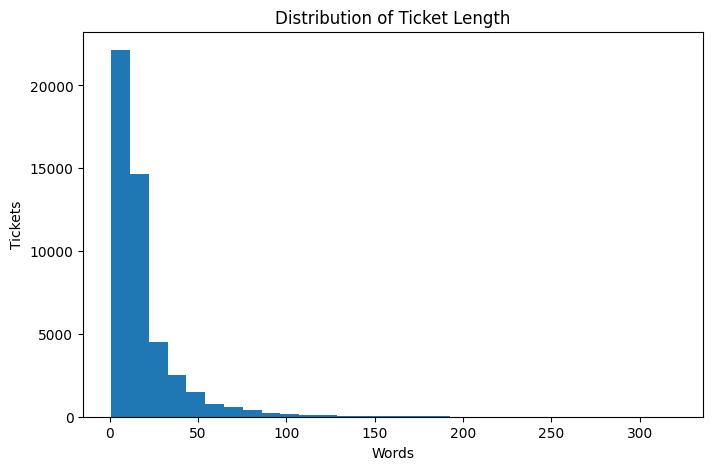

In [93]:
plt.figure(figsize=(8,5))
plt.hist(df['Word Count'], bins=30)
plt.title("Distribution of Ticket Length")
plt.xlabel("Words")
plt.ylabel("Tickets")
plt.savefig("Distribution of Ticket Length.png", dpi=300, bbox_inches='tight')
plt.show()

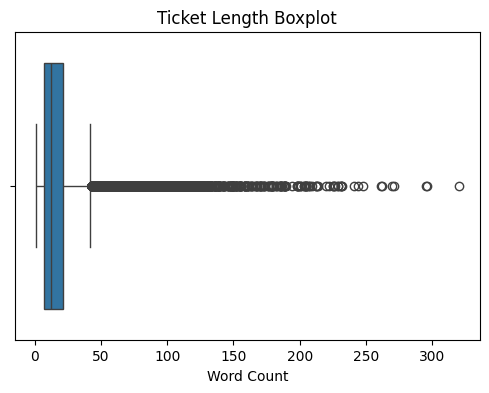

In [94]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Word Count'])
plt.title("Ticket Length Boxplot")
plt.savefig("Ticket Length Boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

In [95]:
df[df['Word Count'] <= 2][['Clean Text', 'Topic_group']].head(20)

,Clean Text,Topic_group
33,access card,access
55,add network,miscellaneous
147,block attach,hr support
213,replacement provide,hardware
226,password recover,access
236,access provide,hr support
335,access resource,hr support
419,right thankyou,storage
439,annual leave,hr support
526,access,hr support


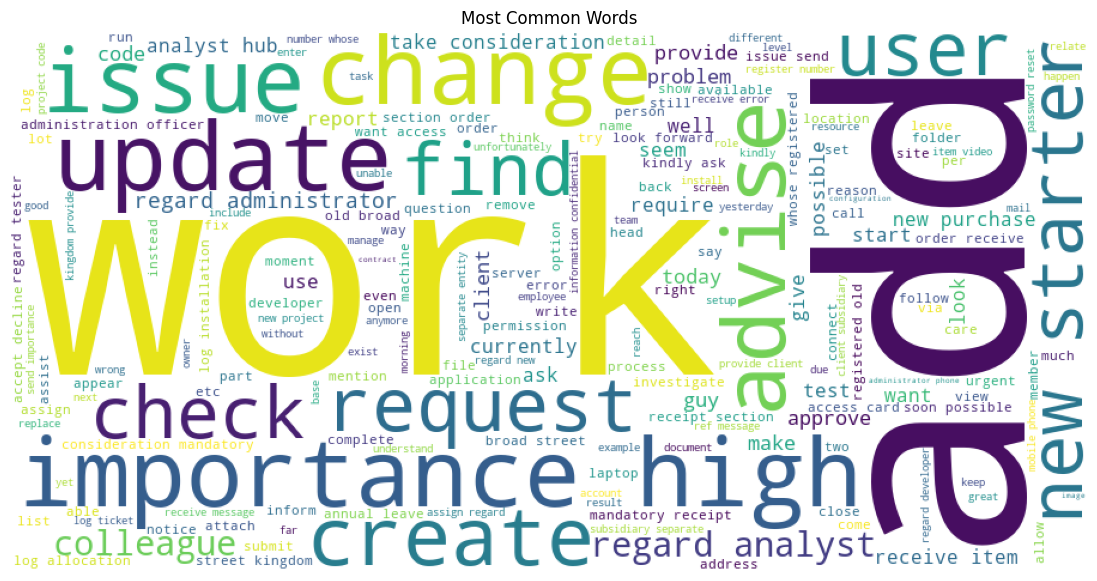

In [96]:
from wordcloud import WordCloud
text = " ".join(df['Clean Text'])
wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='white'
).generate(text)
plt.figure(figsize=(14,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words")
plt.savefig("Most Commom Words.png", dpi=300, bbox_inches='tight')
plt.show()

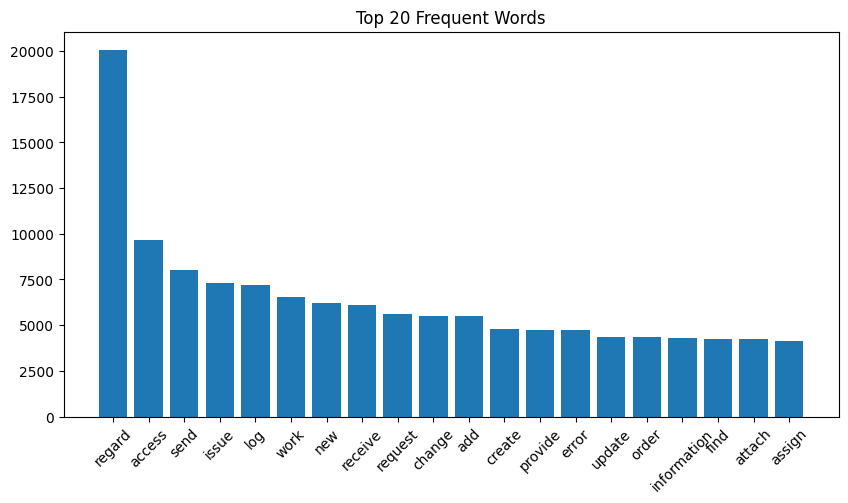

In [48]:
from collections import Counter
text = " ".join(df['Clean Text'])
words=text.split()
counter=Counter(words)
top20=counter.most_common(20)
freq_df=pd.DataFrame(
    top20,
    columns=['Word','Frequency']
)

plt.figure(figsize=(10,5))
plt.bar(freq_df['Word'], freq_df['Frequency'])
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words")
plt.savefig("Top 20 Frequent Words.png", dpi=300, bbox_inches='tight')
plt.show()

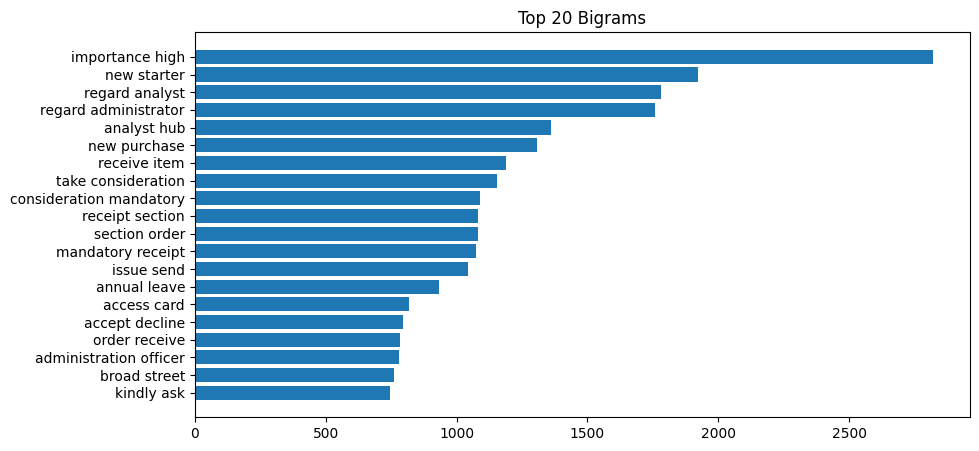

In [49]:
from nltk import bigrams
bigram=list(bigrams(words))
count_bigram=Counter(bigram)
top20_bigrams=count_bigram.most_common(20)
bigram_df = pd.DataFrame(
    top20_bigrams,
    columns=['Bigram','Frequency']
)
#print(bigram_df)
bigram_df['Bigram'] = bigram_df['Bigram'].apply(lambda x: ' '.join(x))
plt.figure(figsize=(10,5))
plt.barh(bigram_df['Bigram'], bigram_df['Frequency'])
plt.title("Top 20 Bigrams")
plt.gca().invert_yaxis()
plt.savefig("Top 20 Bigrams.png", dpi=300, bbox_inches='tight')
plt.show()

In [50]:
bigram_df

,Bigram,Frequency
0,importance high,2819
1,new starter,1922
2,regard analyst,1781
3,regard administrator,1757
4,analyst hub,1362
5,new purchase,1307
6,receive item,1187
7,take consideration,1153
8,consideration mandatory,1091
9,receipt section,1083


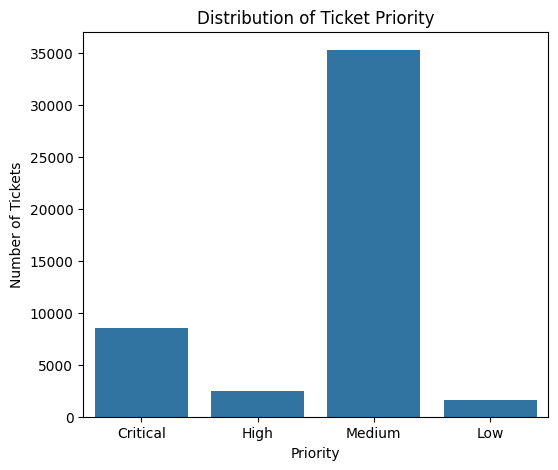

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Priority',
              order=['Critical','High','Medium','Low'])

plt.title('Distribution of Ticket Priority')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')
plt.savefig("Number of Tickets.png", dpi=300, bbox_inches='tight')
plt.show()

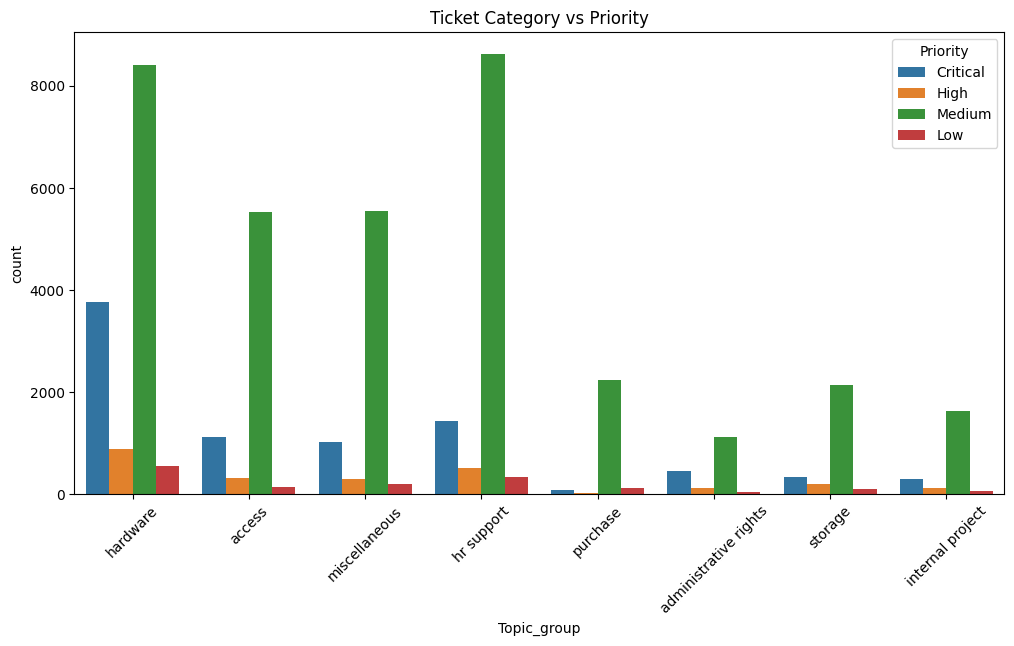

In [42]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='Topic_group',
    hue='Priority',
    hue_order=['Critical','High','Medium','Low']
)

plt.xticks(rotation=45)
plt.title("Ticket Category vs Priority")
plt.savefig("Ticket Category vs Priority.png", dpi=300, bbox_inches='tight')
plt.show()

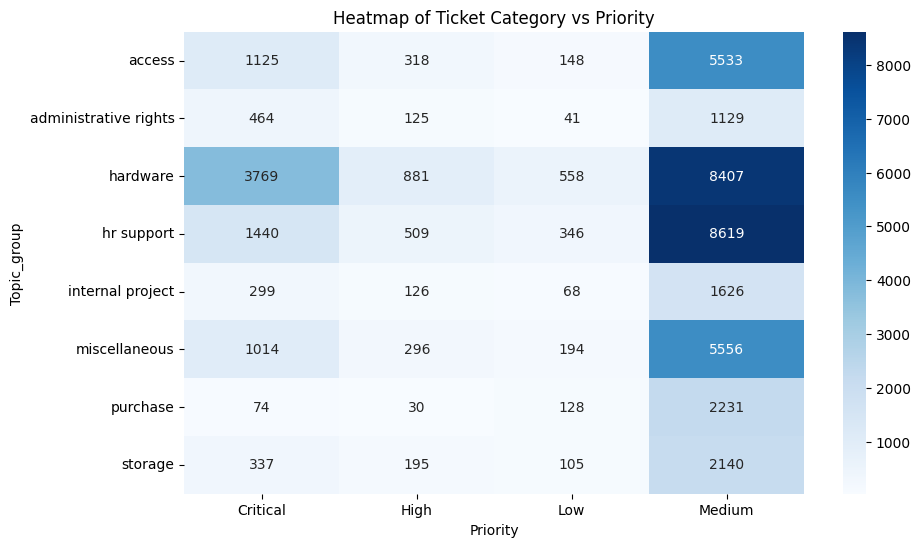

In [43]:
plt.figure(figsize=(10,6))

heat = pd.crosstab(
    df['Topic_group'],
    df['Priority']
)

sns.heatmap(
    heat,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Heatmap of Ticket Category vs Priority")
plt.savefig("Heatmap of Ticket Category vs Priority.png", dpi=300, bbox_inches='tight')
plt.show()

In [44]:
df.isnull().sum()
empty=[(i,s) for i,s in enumerate(df['Clean Text']) if len(s)==0]
empty

[]

In [51]:
df.to_csv("task_df.csv", index=False)
freq_df.to_csv("top_words.csv", index=False)
bigram_df.to_csv("top_bigrams.csv", index=False)